In [54]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [55]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'

raw_df = pd.read_csv(DATA_DIR / 'bus_crowded_raw.csv', encoding='utf-8-sig')
route_df = pd.read_csv(DATA_DIR / 'suwon_route_list.csv', encoding='utf-8-sig', dtype=str)[['route_id', 'source_route_name']].drop_duplicates()

raw_df['route_id'] = raw_df['route_id'].astype(str)
raw_df['collected_at'] = pd.to_datetime(raw_df['collected_at'])
raw_df = raw_df.merge(route_df, on='route_id', how='left')
raw_df['route_name_display'] = raw_df['source_route_name'].fillna(raw_df['route_name'])
raw_df['hour'] = raw_df['collected_at'].dt.hour

raw_df.head()

,collected_at,route_id,route_name,vehicle_id,plate_no,station_seq,station_id,station_name,crowded_code,crowded_label,source_route_name,route_name_display,hour
0,2026-04-08 14:25:15,200000152,NaN,233010497,경기76아5814,11,201000359,NaN,1,여유,15-1,15-1,14
1,2026-04-08 14:25:15,200000152,NaN,233010496,경기76아5813,25,202000206,NaN,1,여유,15-1,15-1,14
2,2026-04-08 14:25:15,200000152,NaN,233010495,경기76아5812,43,203000187,NaN,1,여유,15-1,15-1,14
3,2026-04-08 14:25:15,200000152,NaN,233010494,경기76아5811,54,233000117,NaN,1,여유,15-1,15-1,14
4,2026-04-08 14:25:15,200000152,NaN,233010492,경기76아5809,74,233001879,NaN,1,여유,15-1,15-1,14


In [56]:
print('rows:', len(raw_df))
print('routes:', raw_df['route_id'].nunique())
print('vehicles:', raw_df['vehicle_id'].nunique())
print('start:', raw_df['collected_at'].min())
print('end:', raw_df['collected_at'].max())

rows: 9289
routes: 22
vehicles: 289
start: 2026-04-08 14:25:15
end: 2026-04-09 02:22:48


### 혼잡도 단계별 수집 건수

In [57]:
raw_df['crowded_label'].value_counts().reindex(['여유', '보통', '혼잡', '매우혼잡']).fillna(0)

crowded_label
여유      7741
보통      1277
혼잡       250
매우혼잡      21
Name: count, dtype: int64

C:\Users\human-18\AppData\Local\Temp\ipykernel_3388\2436370635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x='crowded_label', order=['여유', '보통', '혼잡', '매우혼잡'], palette=['#2a9d8f', '#f4a261', '#e76f51', '#b00020'])


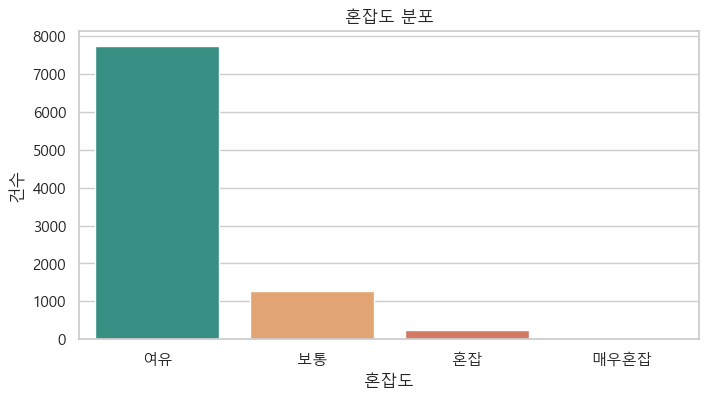

In [58]:
plt.figure(figsize=(8, 4))
sns.countplot(data=raw_df, x='crowded_label', order=['여유', '보통', '혼잡', '매우혼잡'], palette=['#2a9d8f', '#f4a261', '#e76f51', '#b00020'])
plt.title('혼잡도 분포')
plt.xlabel('혼잡도')
plt.ylabel('건수')
plt.show()

### 시간대별 평균 혼잡도

In [59]:
hourly_mean = raw_df.groupby('hour')['crowded_code'].mean()
hourly_mean

hour
0     1.000000
1     1.000000
2     1.000000
14    1.094388
15    1.152593
16    1.282098
17    1.320980
Name: crowded_code, dtype: float64

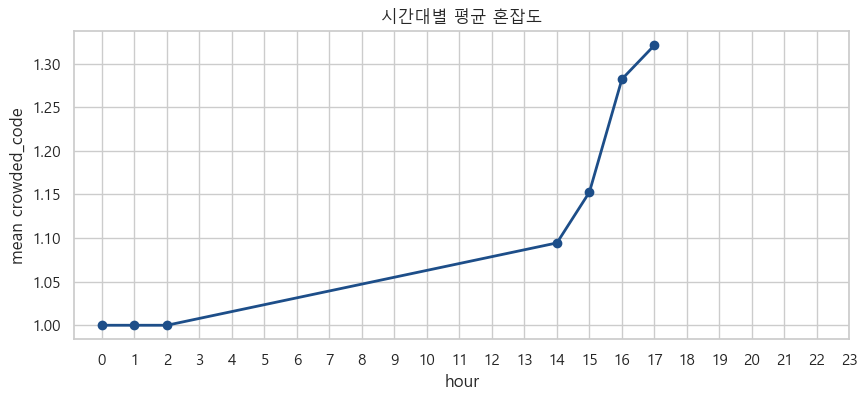

In [60]:
plt.figure(figsize=(10, 4))
plt.plot(hourly_mean.index, hourly_mean.values, marker='o', linewidth=2, color='#1d4e89')
plt.title('시간대별 평균 혼잡도')
plt.xlabel('hour')
plt.ylabel('mean crowded_code')
plt.xticks(range(0, 24))
plt.show()

### 주요 노선별 시간대 평균 혼잡도

In [61]:
major_routes = ['10', '66', '62-1', '720-2', '13-4', '11-1', '20']
route_hour = (
    raw_df[raw_df['route_name_display'].isin(major_routes)]
    .groupby(['route_name_display', 'hour'])['crowded_code']
    .mean()
    .reset_index()
)
pivot = route_hour.pivot(index='route_name_display', columns='hour', values='crowded_code')
pivot

hour,0,1,14,15,16,17
route_name_display,,,,,,
10,1.0,NaN,1.123711,1.303571,1.529070,1.576923
11-1,1.0,NaN,1.030303,1.088496,1.200000,1.211268
13-4,1.0,1.0,1.124088,1.179592,1.356557,1.397163
20,1.0,1.0,1.155556,1.192308,1.186667,1.232558
62-1,1.0,1.0,1.115385,1.218519,1.392593,1.454545
66,1.0,1.0,1.140187,1.137363,1.274194,1.468468
720-2,1.0,1.0,1.117647,1.191571,1.392157,1.443662


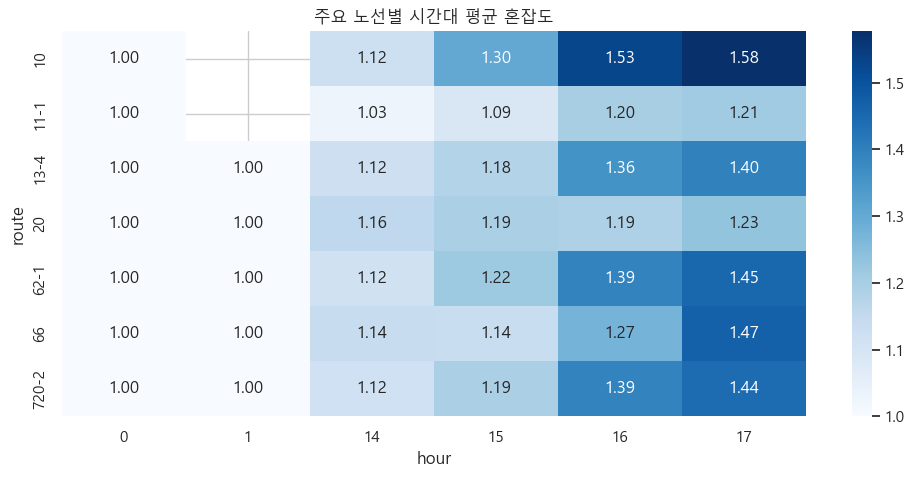

In [62]:
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues')
plt.title('주요 노선별 시간대 평균 혼잡도')
plt.xlabel('hour')
plt.ylabel('route')
plt.show()

### 전처리 실행 결과

In [63]:
subprocess.run(['python', 'preprocess.py'], check=True)

CompletedProcess(args=['python', 'preprocess.py'], returncode=0)

In [64]:
enriched_df = pd.read_csv(DATA_DIR / 'bus_crowded_enriched.csv', encoding='utf-8-sig')
preview_df = pd.read_csv(DATA_DIR / 'model_sequences_preview.csv', encoding='utf-8-sig')

enriched_df.head()

,collected_at,route_id,route_name,vehicle_id,plate_no,station_seq,station_id,station_name,crowded_code,crowded_label,station_seq_diff,direction_code,direction_label,commute_direction
0,2026-04-08 14:25:15,200000013,NaN,233001317,경기76아4758,166,203000434,NaN,1,여유,NaN,0,방향유지,판별보류
1,2026-04-08 14:30:24,200000013,NaN,233001317,경기76아4758,169,203000327,NaN,1,여유,3.0,1,정방향,등교추정
2,2026-04-08 14:35:35,200000013,NaN,233001317,경기76아4758,172,203000279,NaN,1,여유,3.0,1,정방향,등교추정
3,2026-04-08 14:40:42,200000013,NaN,233001317,경기76아4758,175,203000395,NaN,1,여유,3.0,1,정방향,등교추정
4,2026-04-08 14:45:48,200000013,NaN,233001317,경기76아4758,177,203000397,NaN,1,여유,2.0,1,정방향,등교추정


### 방향 추정 결과

In [65]:
enriched_df['commute_direction'].value_counts(dropna=False)

commute_direction
등교추정    8553
판별보류     578
귀가추정     158
Name: count, dtype: int64

C:\Users\human-18\AppData\Local\Temp\ipykernel_3388\2217045269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=enriched_df, x='commute_direction', order=enriched_df['commute_direction'].value_counts().index, palette='Set2')


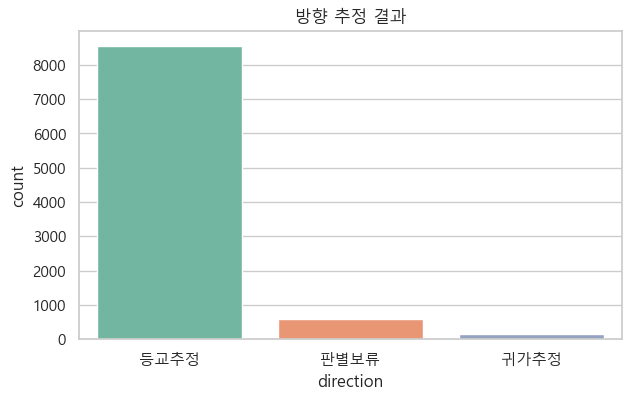

In [66]:
plt.figure(figsize=(7, 4))
sns.countplot(data=enriched_df, x='commute_direction', order=enriched_df['commute_direction'].value_counts().index, palette='Set2')
plt.title('방향 추정 결과')
plt.xlabel('direction')
plt.ylabel('count')
plt.show()

### 시퀀스 데이터 확인

In [67]:
preview_df.head(10)

,route_id,route_name,vehicle_id,target_time,direction_label,commute_direction,input_sequence,target_label
0,200000013,NaN,233001317,2026-04-08 16:23:16,역방향,귀가추정,"[1, 1, 1, 1, 1, 1]",1
1,200000013,NaN,233001317,2026-04-08 16:29:03,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
2,200000013,NaN,233001317,2026-04-08 16:34:07,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
3,200000013,NaN,233001317,2026-04-08 16:39:30,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
4,200000013,NaN,233001317,2026-04-08 16:44:38,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
5,200000013,NaN,233001317,2026-04-08 16:49:44,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
6,200000013,NaN,233001317,2026-04-08 16:54:50,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
7,200000013,NaN,233001317,2026-04-08 16:59:54,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
8,200000013,NaN,233001317,2026-04-08 17:05:00,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",1
9,200000013,NaN,233001317,2026-04-08 17:10:05,정방향,등교추정,"[1, 1, 1, 1, 1, 1]",2


### LSTM / GRU 비교

In [68]:
subprocess.run(['python', 'train_compare.py'], check=True)

CompletedProcess(args=['python', 'train_compare.py'], returncode=0)

In [69]:
compare_df = pd.read_csv(DATA_DIR / 'model_compare_results.csv', encoding='utf-8-sig')
compare_df

,model,epochs_ran,train_loss,train_acc,valid_loss,valid_acc
0,LSTM,22,0.359190,0.874773,0.402336,0.859127
1,GRU,22,0.357584,0.874607,0.399340,0.859788


C:\Users\human-18\AppData\Local\Temp\ipykernel_3388\71091961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x='model', y='valid_acc', palette=['#3a86ff', '#ff006e'], ax=axes[0])
C:\Users\human-18\AppData\Local\Temp\ipykernel_3388\71091961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=compare_df, x='model', y='valid_loss', palette=['#3a86ff', '#ff006e'], ax=axes[1])


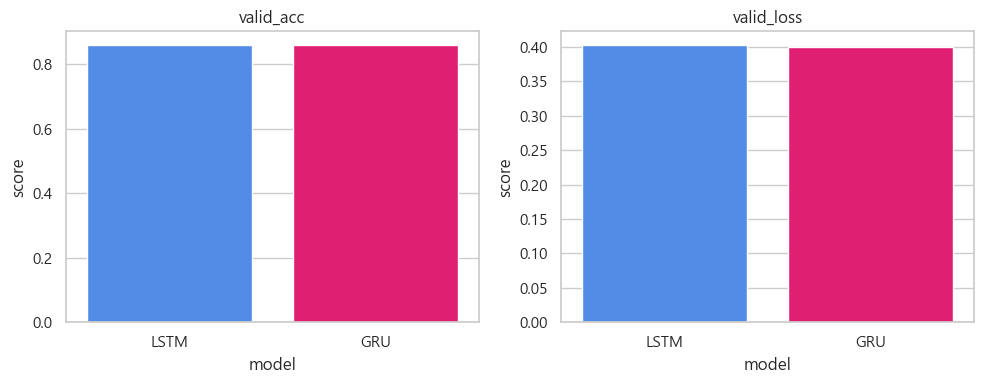

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=compare_df, x='model', y='valid_acc', palette=['#3a86ff', '#ff006e'], ax=axes[0])
axes[0].set_title('valid_acc')
axes[0].set_xlabel('model')
axes[0].set_ylabel('score')

sns.barplot(data=compare_df, x='model', y='valid_loss', palette=['#3a86ff', '#ff006e'], ax=axes[1])
axes[1].set_title('valid_loss')
axes[1].set_xlabel('model')
axes[1].set_ylabel('score')

plt.tight_layout()
plt.show()